In [3]:
# matplotlib에서 출력한 이미지(그래프 포함)은 새 창으로 열림.
%matplotlib qt

import pandas as pd
import mne


""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
# 1. 데이터 불러오고 형태 및 결측치 확인.
file_path = r"../dataset/A01T.gdf"

print("1-1. gdf 데이터 로딩 중--------------")
raw_data = mne.io.read_raw_gdf(file_path, preload=True)


df = raw_data.to_data_frame()

print("1-2. 결측치 확인--------------")
print(df.info())

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
# 2. 채널 타입 정정 및 이름 수정 후, 몽타주 적용
# 2-1. mne 라이브러리가 자동으로 EOG 채널을 EEG 채널이라 저장해둬서 정정해야 함. -> 딕셔너리 이용
print("1. EOG 채널 타입 정정") # -> set_chnnel_types() 사용

eog_dict = {
    'EOG-left': 'eog',
    'EOG-central': 'eog',
    'EOG-right': 'eog'
}

# MNE 객체에 직업 변경 사항을 적용합니다.
raw_data.set_channel_types(eog_dict)



# 2-2. 10-10 시스템(Extended 10-20 system) 표준 명칭으로 이름표 교체 -> Extended 10-20 system은 다양해서 훨씬 많고 다양한 위치의 전극을 허용한다. make_standard_montage('standard_1020')를 통해서 표준 10-20 시스템 뿐만 아니라 확장된 버전도 적용 가능하다. 이것이 10-20 시스템의 장점.(확장성)
print("2. 실험에서 채택한 10-20 시스템의 확장판에 맞게 montage 설정하기 위해 EEG 채널 이름을 표준에 맞는 이름으로 재설정") # -> rename_chnnels() 사용
# 

channel_rename_dict = {
    'EEG-Fz': 'Fz',
    'EEG-0': 'FC3',  'EEG-1': 'FC1',  'EEG-2': 'FCz',  'EEG-3': 'FC2',  'EEG-4': 'FC4',
    'EEG-5': 'C5',   'EEG-C3': 'C3',  'EEG-6': 'C1',   'EEG-Cz': 'Cz',  'EEG-7': 'C2',   'EEG-C4': 'C4',  'EEG-8': 'C6',
    'EEG-9': 'CP3',  'EEG-10': 'CP1', 'EEG-11': 'CPz', 'EEG-12': 'CP2', 'EEG-13': 'CP4',
    'EEG-14': 'P1',  'EEG-Pz': 'Pz',  'EEG-15': 'P2',
    'EEG-16': 'POz'
}
raw_data.rename_channels(channel_rename_dict)


print("2. 10-20 국제 표준 두피 지도를 가져와서 데이터에 씌웁니다.")
# MNE 라이브러리 안에 내장된 'standard_1020' 지도를 꺼내옵니다.
montage = mne.channels.make_standard_montage('standard_1020')

# 꺼내온 지도를 우리 데이터에 찰칵! 하고 덮어씌웁니다.
raw_data.set_montage(montage)

# 지도가 잘 씌워졌는지 머리통 위에서 바라본 2D/3D 센서 위치를 그려봅니다. -> 전극의 실제 위치를 표시한 위의 그림과 이 셀의 channel_rename_dict를 이용해 잘 배치되었는지 확인.
raw_data.plot_sensors(show_names=True)

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
# 3. 이벤트 추출 후 그래프에 합쳐서 뇌파 그래프 보기.

# 3-1. raw 데이터 안에 숨겨진 주석(Annotations)을 컴퓨터가 계산하기 편한 '숫자 배열(events)'로 끄집어냅니다.
events, event_dict = mne.events_from_annotations(raw_data)

# 3-2. 끄집어낸 이벤트가 총 몇 개인지, 어떤 라벨들이 있는지 확인합니다.
print("찾아낸 이벤트 딕셔너리:", event_dict)
print("이벤트 배열의 모양:", events.shape)

# 3-3. 이제 뇌파(raw)와 이벤트(events)를 하나로 합쳐서 시각화합니다!
fig = raw_data.plot(events=events, duration=10.0, n_channels=22, scalings='auto', title="RAW EEG + Event Markers")

1-1. gdf 데이터 로딩 중--------------
Extracting GDF parameters from ../dataset/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


C:\Python312\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


1-2. 결측치 확인--------------
<class 'pandas.DataFrame'>
RangeIndex: 672528 entries, 0 to 672527
Data columns (total 26 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   time         672528 non-null  float64
 1   EEG-Fz       672528 non-null  float64
 2   EEG-0        672528 non-null  float64
 3   EEG-1        672528 non-null  float64
 4   EEG-2        672528 non-null  float64
 5   EEG-3        672528 non-null  float64
 6   EEG-4        672528 non-null  float64
 7   EEG-5        672528 non-null  float64
 8   EEG-C3       672528 non-null  float64
 9   EEG-6        672528 non-null  float64
 10  EEG-Cz       672528 non-null  float64
 11  EEG-7        672528 non-null  float64
 12  EEG-C4       672528 non-null  float64
 13  EEG-8        672528 non-null  float64
 14  EEG-9        672528 non-null  float64
 15  EEG-10       672528 non-null  float64
 16  EEG-11       672528 non-null  float64
 17  EEG-12       672528 non-null  float64
 18  EEG-13   

In [ ]:
import mne
from mne.preprocessing import ICA

print("--- 🚜 최강의 교차 정제 파이프라인 가동 (1~30Hz 광대역 ICA) ---")

# ==========================================
# [트랙 A] 범인 몽타주 확보용 넓은 그물망 (1~30Hz)
# ==========================================
print("1. 모든 노이즈(EOG, 알파파, 근육)를 잡기 위한 1~30Hz 필터링 및 ICA 학습")
raw_for_ica = raw_data.copy().filter(l_freq=1.0, h_freq=30.0)

ica = ICA(n_components=15, max_iter='auto', random_state=97)
ica.fit(raw_for_ica)

# EOG 채널과 비교하여 1차 범인 자동 색출
eog_indices, eog_scores = ica.find_bads_eog(raw_for_ica)
print(f"🕵️‍♂️ 1차 자동 색출된 EOG 성분: {eog_indices}")


# ==========================================
# [트랙 B] AI에게 먹일 진짜 뇌파 준비 (8~30Hz)
# ==========================================
print("2. AI 학습을 위한 8~30Hz 타겟 뇌파 준비")
raw_for_ai = raw_data.copy().filter(l_freq=8.0, h_freq=30.0)
# ==========================================
# [크로스 오버] 트랙 A의 ICA를 트랙 B에 들이받기!
# ==========================================
print("3. 광대역에서 찾은 모든 범인 몽타주를 8~30Hz 데이터에 적용하여 영구 제외")
raw_clean = raw_for_ai.copy()


# 핵심: 1~30Hz에서 똑똑하게 학습된 ica를 8~30Hz 타겟 데이터에 적용!
ica.apply(raw_clean, exclude=eog_indices)
# 2. CAR 적용 (전압 기준점 평탄화)
raw_clean.set_eeg_reference('average', projection=False)
"""
# 4. 정제 결과 확인
raw_for_ai.plot(n_channels=5, title="Before ICA (8-30Hz)")
raw_clean.plot(n_channels=5, title="After ICA (8-30Hz Cleaned)")
"""
print("--- 🎉 무결점 정제 완료! ---")


# ------------------------------------------------------- 에포킹

print("--- 🚜 9일 차: 에포킹 불도저 가동 ---")

# 1. 뇌파 데이터 안에 숨겨진 '지시 타이밍(이벤트)' 추출
events, event_dict = mne.events_from_annotations(raw_clean)
print(f"발견된 이벤트 종류: {event_dict}")

# 2. 데이터 싹둑 썰기
# 수정 전: tmin=-1.0, tmax=4.0 (총 5초 섞임)
# 수정 후: 지시가 내려지고(0.0) 약간의 인지 지연이 지난 후부터, 집중력이 끝나는 시점까지만 싹둑!
epochs = mne.Epochs(raw_clean, events, tmin=0.5, tmax=3.5, event_id=event_dict, baseline=None, preload=True, event_repeated="drop")


--- 🚜 최강의 교차 정제 파이프라인 가동 (1~30Hz 광대역 ICA) ---
1. 모든 노이즈(EOG, 알파파, 근육)를 잡기 위한 1~30Hz 필터링 및 ICA 학습
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 825 samples (3.300 s)

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 31.5s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and rev

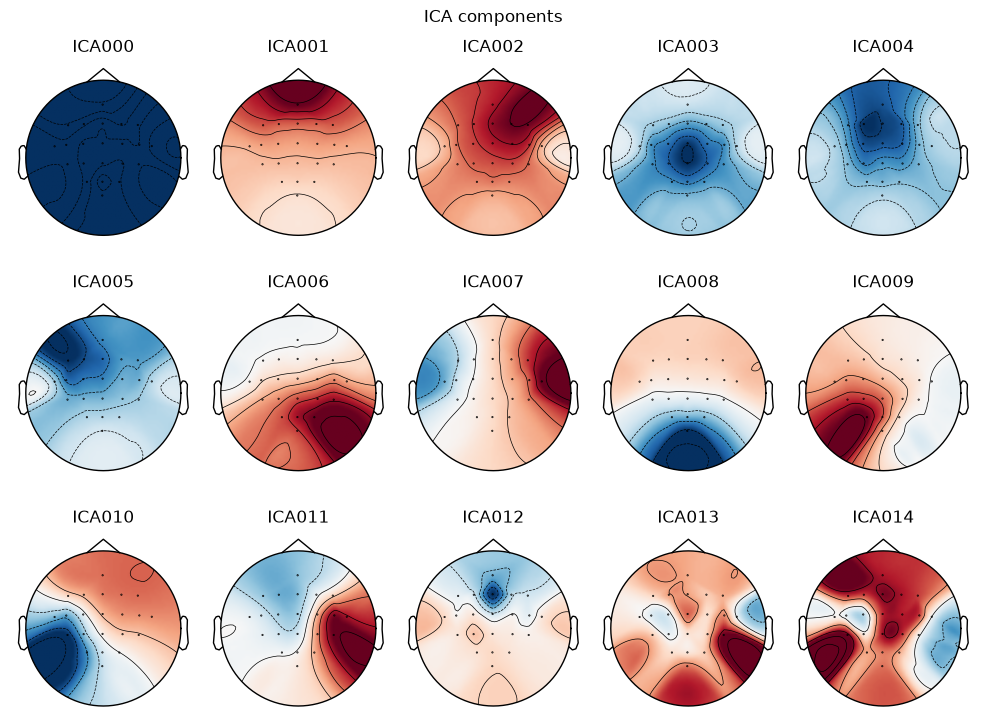

In [ ]:
# 1차 자동 색출된 EOG 성분: [np.int64(0), np.int64(1), np.int64(7)]
ica.plot_components()

--- 🚜 12~13일 차: 타겟팅 CSP 불도저 가동 ---
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Computing rank from data with rank=None
    Using tolerance 5.9e-06 (2.2e-16 eps * 17 dim * 1.6e+09  max singular value)
    Estimated rank (data): 17
    data: rank 17 computed from 17 data channels with 0 projectors
Reducing data rank from 17 -> 17
Estimating class=7 covariance using LEDOIT_WOLF
Done.
Estimating class=8 covariance using LEDOIT_WOLF
Done.
CSP 돋보기 학습 완료!
NOTE: plot_patterns() is a legacy function. New code should use get_spatial_filter_from_estimator(clf, info=info).plot_patterns().


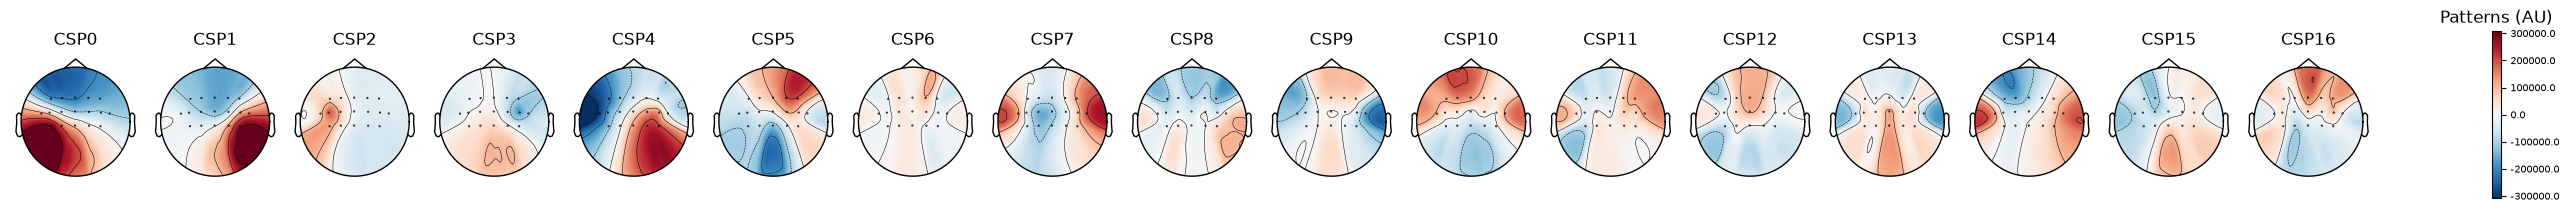

In [ ]:
from mne.decoding import CSP

print("--- 🚜 12~13일 차: 타겟팅 CSP 불도저 가동 ---")

# 1. 핀셋 타겟팅: 왼손(769)과 오른손(770) 상상 데이터만 추출
epochs_mi = epochs['769', '770'] 
epochs_mi_eeg = epochs_mi.copy().pick_types(eeg=True, eog=False)
# 2. 순수 EEG 채널 중에서도 앞/뒤 뇌파를 잘라내고 '운동 피질' 주변만 핀셋 추출
# C(중심엽), FC(전두중심엽), CP(중심두정엽) 라인의 전극만 선택하여 모델의 시야를 강제로 좁힙니다.
motor_channels = ['FC3', 'FC1', 'FCz', 'FC2', 'FC4', 
                  'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 
                  'CP3', 'CP1', 'CPz', 'CP2', 'CP4']

# 기존 22개 차원에서 17개 차원으로 축소
epochs_mi_motor = epochs_mi_eeg.copy().pick_channels(motor_channels)
# 2. 머신러닝 모델에 넣을 3차원 특징 데이터(X)와 정답 라벨(y) 분리
X = epochs_mi_motor.get_data(copy=True) # epochs.get_data()는 (Epochs, Channels, Time) 형태의 3차원 배열을 반환합니다.
y = epochs_mi_motor.events[:, -1] # 이벤트 배열의 마지막 열이 라벨(예: 769, 770)입니다.

# 3. CSP 모델 생성 및 학습
# 수정할 부분
csp = CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=True)
csp.fit(X, y)
print("CSP 돋보기 학습 완료!")

# 4. CSP 공간 패턴 시각화
csp.plot_patterns(epochs_mi_motor.info, ch_type='eeg', units='Patterns (AU)', size=1.5)





# 1. 계산된 CSP 필터를 사용하여 원본 뇌파 데이터(X)를 핵심 특징 공간으로 투영(압축)합니다.
X_features = csp.transform(X)

# 2. 텐서 구조의 변화를 시각적으로 확인합니다.
print(f"변환 전 원본 데이터 X의 형태: {X.shape}")
print(f"변환 후 AI 학습용 X_features의 형태: {X_features.shape}")
# 결과인 (144,4)를 보면 144는 왼손(7) 혹은 오른손(8)을 나타내는 문제 개수이다. 4는 CSP에서 뽑은 것중 맨 앞 2개, 맨 뒤 2개의 csp 패턴이다.(n_components=4)
# 그래프를 그리면 4차원 상의 144개의 점이 흩뿌려져 있는 모양이다. 각 점은 4개 차원(csp 4개 패턴)이 각각 얼마나 분산을 증폭시켜주는지에 따라 분포할 것이다.
# 즉, 그래프를 보면 어떤 점은 앞쪽 2개의 csp 패턴쪽으로 치우쳐질 거고, 다른 점은 뒤쪽 2개의 csp 패턴쪽으로 치우쳐질 것이다.(앞쪽은 왼손 클래스의 분산 최대로, 뒷쪽 csp는 오른손 클래스 분산 최대로)
# 다음에 나올 SVM이나 LDA는 이런 그래프에 선을 긋는 역할을 한다. 이렇게 해서 

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 사용자가 추출한 CSP 특징(X_features)과 정답 라벨(y)을 그대로 사용합니다.
# 변수명이 다를 경우 아래 X_features, y 부분만 맞춰서 수정하십시오.

# 1. LDA 베이스라인 (Train/Test 분리)
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2, random_state=42)

lda = LDA()
lda.fit(X_train, y_train)
lda_pred = lda.predict(X_test)
print(f"LDA 단일 Test 정확도: {accuracy_score(y_test, lda_pred):.2f}")

# 2. 교차 검증(K-Fold) 및 SVM 비교
svm = SVC(kernel='rbf') # rbf로 설정하면 구분선이 직선이 아닌 곡선이 됨.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

lda_scores = cross_val_score(lda, X_features, y, cv=cv)
svm_scores = cross_val_score(svm, X_features, y, cv=cv)

print(f"LDA 5-Fold 평균 정확도: {np.mean(lda_scores):.2f}")
print(f"SVM 5-Fold 평균 정확도: {np.mean(svm_scores):.2f}")

# 3. 혼동 행렬 시각화 (SVM 결과 기준)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6, 5))
# xticklabels, yticklabels는 실제 타겟(예: 왼손, 오른손)에 맞게 변경해도 좋습니다.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('SVM Confusion Matrix')
plt.show()